## Functions

In [49]:
import numpy as np
import ast
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [50]:
def open_file(file_path, print_header=True):
# Open file
    with open(file_path, 'r') as f:
        first_line = f.readline()

    # Obtain header information 
    header_str = first_line[first_line.find("{"):].strip() 
    header_dict = ast.literal_eval(header_str)
    
    # Print header information
    if print_header:
        print("-"*40)
        print("FILE DATA:")
        print("-"*40)
        for key, value in header_dict.items():
            print(f"{key}: {value}")

    # Calculate splitter loss and adjust power values
    if header_dict['splitter'] == 'na':
        splitter_opm_loss = 0
        splitter_osa_loss = 0
    else:
        splitter_loss = header_dict['splitter'].split('-')[-1].split('/')
        splitter_opm_loss = 10*np.log10(float(splitter_loss[1])/100)
        splitter_osa_loss = 10*np.log10(float(splitter_loss[0])/100)

    print("-"*40)
    print(f"Adjusted OPM Power to Splitter Loss: {header_dict['opm_power']-splitter_opm_loss} dBm")

    # Load wavelength and power data, adjust power values to splitter loss, and plot
    wavelength, power = np.loadtxt(file_path, comments='%', unpack=True)
    wavelength = wavelength.astype('float')
    power = power.astype('float')

    return wavelength-splitter_osa_loss, power


def find_minima(power, wavelength, threshold, separation):
    power_inverted = -power

    avg_step = np.mean(np.diff(wavelength))
    dist_points = int(separation/ avg_step)

    indices, properties = find_peaks(power_inverted, prominence=threshold, distance=dist_points)

    return indices

## Initialization

In [51]:
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-5/2/6\u2.txt" # Read mode so \u... is not interpreted as unicode

threshold = 1.5    # For minima detection (dB)
separation = 2     # Minimum separation between minima (nm)

window_size = 10   # Window for zooming in on minima (nm)
idx_min = 2        # Index of the minumum to zoom in (0, 1, 2, ...)

wavelength, power = open_file(file_path, print_header=True)

----------------------------------------
FILE DATA:
----------------------------------------
datetime: 2026_02_12_13_24_24
operator: Joan Aroca
setup: P2.S2
project: PHYSIS
wafer: 17753-5
reticle: 2
die: 6
dut: u2
polarization: nana
die_temperature: na
coupling_type: SM-SM
idsource: ASE1
idosa: OSA20
operator_notes: NA
opm_power: -19.27
splitter: 1x2-95/5
coupler_2X2_90_10_SN: none
osa_idn: EXFO,OSA20 FC/APC,YO161110143,2.0.6.0
osa_resolution: 5e-11
osa_sensitivity: 4.0
osa_start_wavelength: 1.5e-06
osa_stop_wavelength: 1.6e-06
osa_sweep_mode: SINGLE
osa_integrated_power: 0.0
osa_dBm_nm: False
----------------------------------------
Adjusted OPM Power to Splitter Loss: -6.259700043360187 dBm


## Code

In [52]:
# ASE1 range
wl_0 = 1530 
wl_1 = 1600

# Filter wavelength and power data to the range of interest
wavelength_filtered = wavelength[(wavelength >= wl_0) & (wavelength < wl_1)]
power_filtered = power[(wavelength >= wl_0) & (wavelength < wl_1)]

# Calculate power difference with waveguide measurement
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-5/2/6\wvg.txt" 
wavelength_2, power_2 = open_file(file_path, print_header=False)

power_2_filtered = power_2[(wavelength_2 >= wl_0) & (wavelength_2 <= wl_1)]
power_difference = power_filtered - power_2_filtered

# Find minima in power transmission
indices = find_minima(power_difference, wavelength_filtered, threshold, separation)

wavelengths_min = wavelength_filtered[indices]
power_min = power_filtered[indices]
power_diff_min = power_difference[indices]

# Zoom in on the desired minimum
wl_0 = wavelengths_min[idx_min] - window_size/2
wl_1 = wavelengths_min[idx_min] + window_size/2

power_windowed = power_filtered[(wavelength_filtered >= wl_0) & (wavelength_filtered <= wl_1)]
wavelengths_windowed= wavelength_filtered[(wavelength_filtered >= wl_0) & (wavelength_filtered <= wl_1)]

----------------------------------------
Adjusted OPM Power to Splitter Loss: -6.259700043360187 dBm


## Output

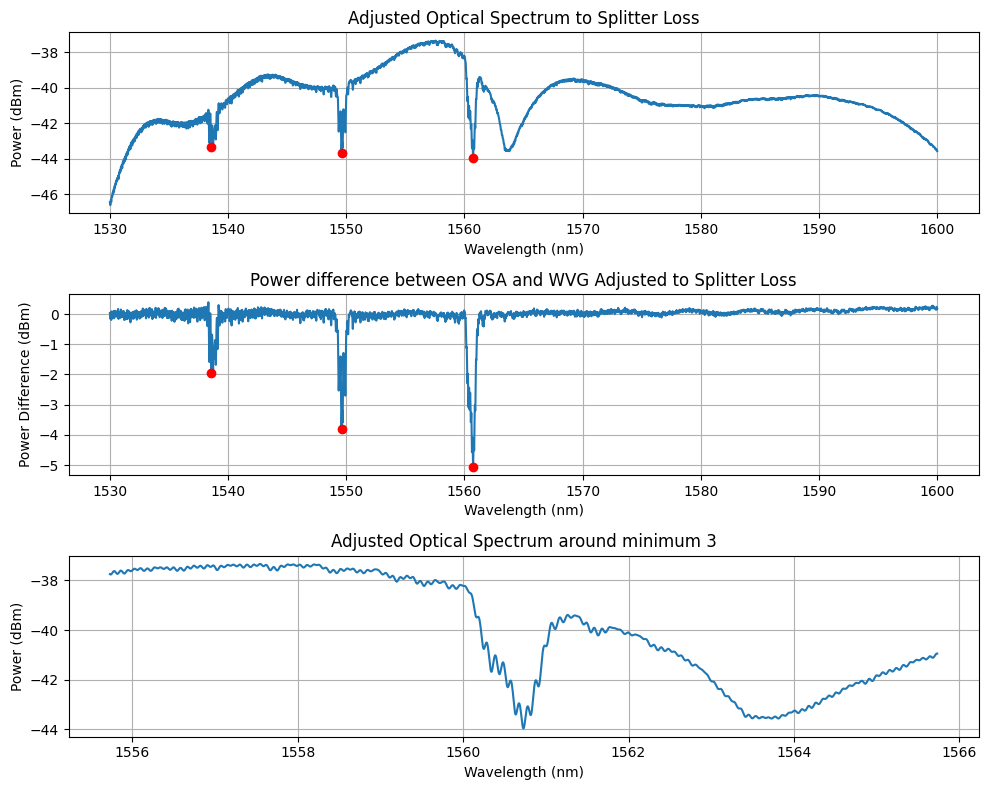

In [53]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
axs[0].plot(wavelength_filtered, power_filtered)
axs[0].plot(wavelengths_min, power_min, "ro")
axs[0].set_title("Adjusted Optical Spectrum to Splitter Loss")
axs[0].set_xlabel("Wavelength (nm)")
axs[0].set_ylabel("Power (dBm)")
axs[0].grid()   

axs[1].plot(wavelength_filtered, power_difference)
axs[1].plot(wavelengths_min, power_diff_min, "ro")
axs[1].set_title("Power difference between OSA and WVG Adjusted to Splitter Loss")
axs[1].set_xlabel("Wavelength (nm)")
axs[1].set_ylabel("Power Difference (dBm)")
axs[1].grid()

axs[2].plot(wavelengths_windowed, power_windowed)
axs[2].set_title(f"Adjusted Optical Spectrum around minimum {idx_min+1}")
axs[2].set_xlabel("Wavelength (nm)")
axs[2].set_ylabel("Power (dBm)")
axs[2].grid()
plt.tight_layout()
plt.show()